#Section 1 - Environment Setup

In [1]:
import torch

print("PyTorch Version:", torch.__version__)
print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

PyTorch Version: 2.11.0+cpu
GPU Available: False


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

project_dir = "/content/drive/MyDrive/RemoteSensing_Internship"
os.makedirs(project_dir, exist_ok=True)
print("Project directory:", project_dir)

Project directory: /content/drive/MyDrive/RemoteSensing_Internship


In [4]:
%cd /content/drive/MyDrive/RemoteSensing_Internship

/content/drive/MyDrive/RemoteSensing_Internship


In [5]:
!pip install -q timm datasets

#Section 2 - Download PatternNet (via Hugging Face) and Inspect



In [6]:
from datasets import load_dataset

hf_dataset = load_dataset("blanchon/PatternNet", split="train")
print(hf_dataset)

README.md:   0%|          | 0.00/4.11k [00:00<?, ?B/s]

data/train-00000-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  426MB            

data/train-00000-of-00003.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  473MB            

data/train-00001-of-00003.parquet: downloading bytes:           |  0.00B            

data/train-00002-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  524MB            

data/train-00002-of-00003.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/30400 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'label'],
    num_rows: 30400
})


In [7]:
print("Number of samples:", len(hf_dataset))
print("Features:", hf_dataset.features)
print("First example (metadata only):")
example = hf_dataset[0]
print({k: v for k, v in example.items() if k != "image"})
print("Image size:", example["image"].size)

Number of samples: 30400
Features: {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['airplane', 'baseball field', 'basketball court', 'beach', 'bridge', 'cemetery', 'chaparral', 'christmas tree farm', 'closed road', 'coastal mansion', 'crosswalk', 'dense residential', 'ferry terminal', 'football field', 'forest', 'freeway', 'golf course', 'harbor', 'intersection', 'mobile home park', 'nursing home', 'oil gas field', 'oil well', 'overpass', 'parking lot', 'parking space', 'railway', 'river', 'runway', 'runway marking', 'shipping yard', 'solar panel', 'sparse residential', 'storage tank', 'swimming pool', 'tennis court', 'transformer station', 'wastewater treatment plant'])}
First example (metadata only):
{'label': 0}
Image size: (256, 256)


In [10]:
print("Features:", hf_dataset.features)
print("Column names:", hf_dataset.column_names)

Features: {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['airplane', 'baseball field', 'basketball court', 'beach', 'bridge', 'cemetery', 'chaparral', 'christmas tree farm', 'closed road', 'coastal mansion', 'crosswalk', 'dense residential', 'ferry terminal', 'football field', 'forest', 'freeway', 'golf course', 'harbor', 'intersection', 'mobile home park', 'nursing home', 'oil gas field', 'oil well', 'overpass', 'parking lot', 'parking space', 'railway', 'river', 'runway', 'runway marking', 'shipping yard', 'solar panel', 'sparse residential', 'storage tank', 'swimming pool', 'tennis court', 'transformer station', 'wastewater treatment plant'])}
Column names: ['image', 'label']


In [11]:
class_names = hf_dataset.features['label'].names

print("Number of Classes:", len(class_names))
for i, c in enumerate(class_names):
    print(i, c)

Number of Classes: 38
0 airplane
1 baseball field
2 basketball court
3 beach
4 bridge
5 cemetery
6 chaparral
7 christmas tree farm
8 closed road
9 coastal mansion
10 crosswalk
11 dense residential
12 ferry terminal
13 football field
14 forest
15 freeway
16 golf course
17 harbor
18 intersection
19 mobile home park
20 nursing home
21 oil gas field
22 oil well
23 overpass
24 parking lot
25 parking space
26 railway
27 river
28 runway
29 runway marking
30 shipping yard
31 solar panel
32 sparse residential
33 storage tank
34 swimming pool
35 tennis court
36 transformer station
37 wastewater treatment plant


In [12]:
example = hf_dataset[0]
print("Image size:", example["image"].size)
print("Image mode:", example["image"].mode)
print("Label index:", example["label"])
print("Label name:", class_names[example["label"]])

Image size: (256, 256)
Image mode: RGB
Label index: 0
Label name: airplane


#Section 3 - Materialize to Local Folder Structure


In [15]:
import os

patternnet_dir = "/content/PatternNet_images"   # local Colab disk, not Drive — much faster I/O for this step
os.makedirs(patternnet_dir, exist_ok=True)

# Create one subfolder per class, using underscores instead of spaces
# (spaces in folder names can cause issues later, and match the original class naming convention)
class_folder_names = [c.replace(" ", "_") for c in class_names]

for folder_name in class_folder_names:
    os.makedirs(os.path.join(patternnet_dir, folder_name), exist_ok=True)

print("Created", len(class_folder_names), "class folders")
print("Example:", class_folder_names[:5])

Created 38 class folders
Example: ['airplane', 'baseball_field', 'basketball_court', 'beach', 'bridge']


In [16]:
from collections import defaultdict
import time

counters = defaultdict(int)
start_time = time.time()

for i, example in enumerate(hf_dataset):
    label_idx = example["label"]
    folder_name = class_folder_names[label_idx]
    img = example["image"]

    counters[folder_name] += 1
    filename = f"{folder_name}_{counters[folder_name]:04d}.jpg"
    filepath = os.path.join(patternnet_dir, folder_name, filename)

    img.save(filepath, "JPEG")

    if (i + 1) % 5000 == 0:
        elapsed = time.time() - start_time
        print(f"Saved {i+1}/{len(hf_dataset)} images... ({elapsed:.1f}s elapsed)")

print(f"Done. Total time: {time.time() - start_time:.1f}s")

Saved 5000/30400 images... (13.6s elapsed)
Saved 10000/30400 images... (28.1s elapsed)
Saved 15000/30400 images... (39.2s elapsed)
Saved 20000/30400 images... (49.5s elapsed)
Saved 25000/30400 images... (60.1s elapsed)
Saved 30000/30400 images... (71.2s elapsed)
Done. Total time: 71.8s


In [17]:
total_saved = sum(len(os.listdir(os.path.join(patternnet_dir, f))) for f in class_folder_names)
print("Total images saved to disk:", total_saved)

# Spot-check one folder
sample_folder = class_folder_names[0]
sample_files = os.listdir(os.path.join(patternnet_dir, sample_folder))[:5]
print(f"\nSample files in '{sample_folder}':")
print(sample_files)

Total images saved to disk: 30400

Sample files in 'airplane':
['airplane_0427.jpg', 'airplane_0314.jpg', 'airplane_0226.jpg', 'airplane_0540.jpg', 'airplane_0070.jpg']


#Section 4 - ImageFolder, Split, and DataLoaders

In [18]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = ImageFolder(root=patternnet_dir, transform=transform)

print("Total Images:", len(dataset))
print("Number of Classes:", len(dataset.classes))
for i, c in enumerate(dataset.classes):
    print(i, c)

Total Images: 30400
Number of Classes: 38
0 airplane
1 baseball_field
2 basketball_court
3 beach
4 bridge
5 cemetery
6 chaparral
7 christmas_tree_farm
8 closed_road
9 coastal_mansion
10 crosswalk
11 dense_residential
12 ferry_terminal
13 football_field
14 forest
15 freeway
16 golf_course
17 harbor
18 intersection
19 mobile_home_park
20 nursing_home
21 oil_gas_field
22 oil_well
23 overpass
24 parking_lot
25 parking_space
26 railway
27 river
28 runway
29 runway_marking
30 shipping_yard
31 solar_panel
32 sparse_residential
33 storage_tank
34 swimming_pool
35 tennis_court
36 transformer_station
37 wastewater_treatment_plant


In [19]:
class_names = dataset.classes   # overwrite to keep consistent naming with your other notebooks
dataset_size = len(dataset)
train_size = int(0.8 * dataset_size)
val_size = int(0.1 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("Training Images:", len(train_dataset))
print("Validation Images:", len(val_dataset))
print("Testing Images:", len(test_dataset))

Training Images: 24320
Validation Images: 3040
Testing Images: 3040


In [20]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

images, labels = next(iter(train_loader))
print("Image Batch Shape:", images.shape)
print("Label Batch Shape:", labels.shape)

Image Batch Shape: torch.Size([32, 3, 224, 224])
Label Batch Shape: torch.Size([32])


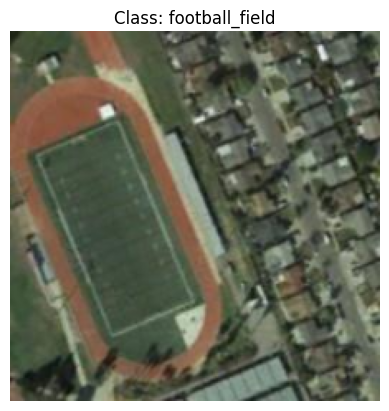

In [21]:
import matplotlib.pyplot as plt

img = images[0].permute(1, 2, 0)
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])
img = img * std + mean
img = img.clamp(0, 1)

plt.imshow(img)
plt.title(f"Class: {class_names[labels[0]]}")
plt.axis('off')
plt.show()

#Section 5 - MambaOut Model Setup

In [22]:
import timm

NUM_CLASSES = len(class_names)   # 38 for PatternNet

model = timm.create_model(
    "mambaout_tiny",
    pretrained=False,
    num_classes=NUM_CLASSES
)

print(model.default_cfg)

{'url': '', 'hf_hub_id': 'timm/mambaout_tiny.in1k', 'architecture': 'mambaout_tiny', 'tag': 'in1k', 'custom_load': False, 'input_size': (3, 224, 224), 'test_input_size': (3, 288, 288), 'fixed_input_size': False, 'interpolation': 'bicubic', 'crop_pct': 1.0, 'crop_mode': 'center', 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'num_classes': 1000, 'pool_size': (7, 7), 'first_conv': 'stem.conv1', 'classifier': 'head.fc', 'license': 'apache-2.0'}


In [23]:
import timm

NUM_CLASSES = len(class_names)   # 38 for PatternNet

model = timm.create_model(
    "mambaout_tiny",
    pretrained=False,
    num_classes=NUM_CLASSES
)

print(model.default_cfg)

{'url': '', 'hf_hub_id': 'timm/mambaout_tiny.in1k', 'architecture': 'mambaout_tiny', 'tag': 'in1k', 'custom_load': False, 'input_size': (3, 224, 224), 'test_input_size': (3, 288, 288), 'fixed_input_size': False, 'interpolation': 'bicubic', 'crop_pct': 1.0, 'crop_mode': 'center', 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'num_classes': 1000, 'pool_size': (7, 7), 'first_conv': 'stem.conv1', 'classifier': 'head.fc', 'license': 'apache-2.0'}


In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(device)

cpu


#Section 6 - Training Setup

In [26]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss()
print(criterion)

CrossEntropyLoss()


In [27]:
import torch.optim as optim

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print(optimizer)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)


In [28]:
scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=7,
    gamma=0.1
)

print(scheduler)

#Section 7 - Training Loop

In [29]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

In [30]:
EPOCHS = 15

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

In [ ]:
best_accuracy = 0
import time

start_time = time.time()

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    scheduler.step()

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Accuracy : {train_acc:.2f}%")
    print(f"Validation Loss : {val_loss:.4f}")
    print(f"Validation Accuracy : {val_acc:.2f}%")
    print("-"*40)

    if val_acc > best_accuracy:
        best_accuracy = val_acc
        torch.save(model.state_dict(), "best_mambaout_patternnet.pth")

end_time = time.time()
training_time = end_time - start_time

print(f"Training Time: {training_time:.2f} seconds")
print("Training Finished!")
print("Best Validation Accuracy:", best_accuracy)

#Section 8 - Evaluation

In [ ]:
model.load_state_dict(torch.load("best_mambaout_patternnet.pth"))
model.eval()
print("Best model loaded successfully!")

In [ ]:
test_loss, test_accuracy = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

In [ ]:
import torch.nn.functional as F

all_preds = []
all_labels = []
all_probs = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(18, 16))
sns.heatmap(
    cm,
    annot=False,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("MambaOut — PatternNet Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, target_names=class_names))

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')
auc = roc_auc_score(all_labels, np.array(all_probs), multi_class='ovr', average='macro')

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC       : {auc:.4f}")

#Section 9 - Training Curves


In [ ]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, marker='o', label="Train Loss")
plt.plot(val_losses, marker='o', label="Validation Loss")
plt.title("MambaOut PatternNet — Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(train_accuracies, marker='o', label="Train Accuracy")
plt.plot(val_accuracies, marker='o', label="Validation Accuracy")
plt.title("MambaOut PatternNet — Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()

#Section 10 - Results Summary

In [ ]:
print("="*50)
print("MambaOut Results — PatternNet")
print("="*50)
print(f"Training Time : {training_time:.2f} sec")
print(f"Training Loss : {train_losses[-1]:.4f}")
print(f"Validation Loss : {val_losses[-1]:.4f}")
print(f"Training Accuracy : {train_accuracies[-1]:.2f}%")
print(f"Validation Accuracy : {val_accuracies[-1]:.2f}%")
print(f"Test Accuracy : {test_accuracy:.2f}%")
print(f"Precision : {precision:.4f}")
print(f"Recall : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUC : {auc:.4f}")